### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20U-DiT%20mini.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FMNIST%2520U-DiT%2520mini.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FMNIST%20U-DiT%20mini.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20U-DiT%20mini.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [ ]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, repository=REPOSITORY, revision=REVISION,
    runtime=RUNTIME, cuda=CUDA,
)


In [ ]:
import init

In [2]:
epochs = 50

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    dim=16, 
    dim_forced=False, 
    depth=11, 
    cross_attention_ids_dict={9: (3,), 11: (1,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 9, 11], 
    use_decoder_ids=[9, 11], 
    vit_block_mlp_output_dims={1: 16, 3: 32, 5: 32, 9: 16, 11: 16}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos"
    }, 
    upsample_ids=[8, 10], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }
)
model = DiffusionModel(network=vit)

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 16)          80        
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 16)               16000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 16)               176       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 16)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 16)

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=2.5e-3, 
    decay_steps=epochs * len(trainset), 
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
    # run_eagerly=True
)

In [ ]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/50
468/468 [==============================] - 57s 93ms/step - noise_loss: 0.9584 - val_loss: 0.9975 - val_noise_loss: 0.9975 - val_image_loss: 36.5118 - learning_rate: 0.0025


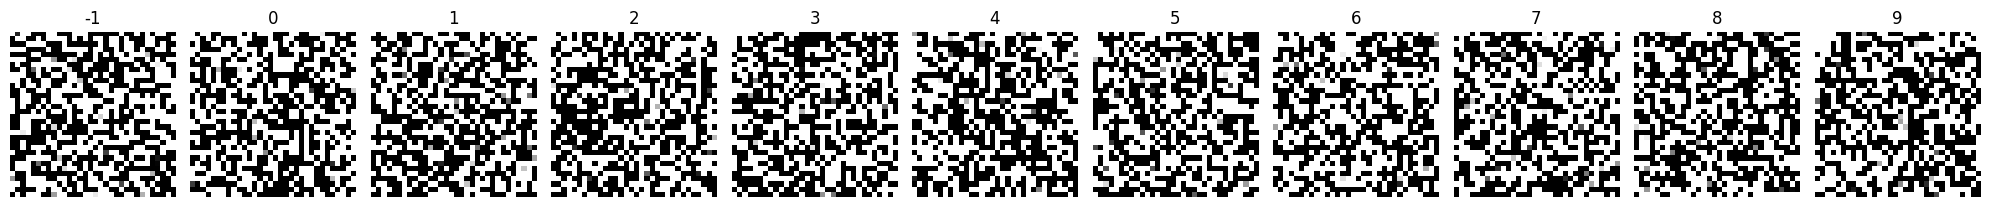

Epoch 2/50
468/468 [==============================] - 42s 89ms/step - noise_loss: 0.2996 - val_loss: 1.0049 - val_noise_loss: 1.0049 - val_image_loss: 35.4412 - learning_rate: 0.0025


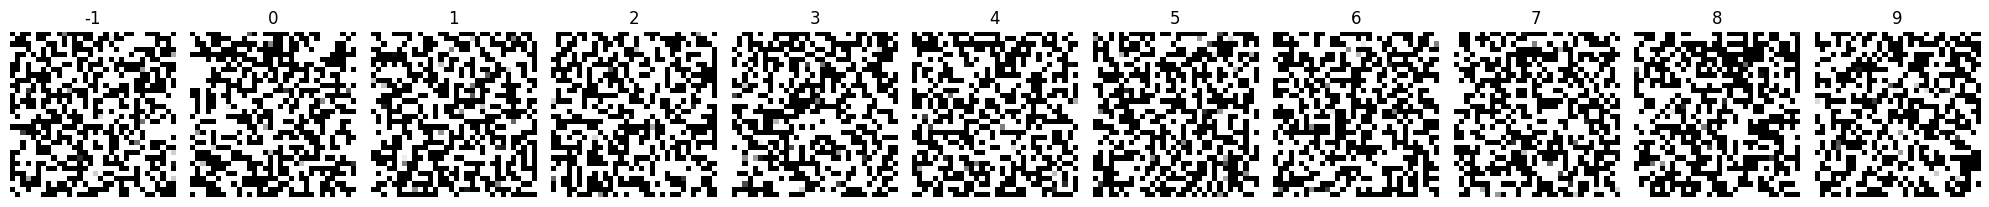

Epoch 3/50
468/468 [==============================] - 42s 90ms/step - noise_loss: 0.0678 - val_loss: 1.1091 - val_noise_loss: 1.1091 - val_image_loss: 38.3540 - learning_rate: 0.0025


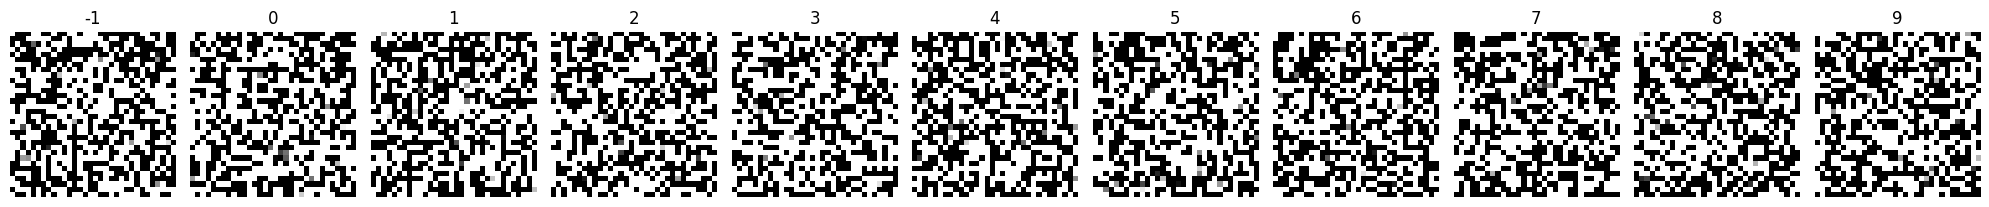

Epoch 4/50
468/468 [==============================] - 44s 94ms/step - noise_loss: 0.2155 - val_loss: 1.0252 - val_noise_loss: 1.0252 - val_image_loss: 34.9282 - learning_rate: 0.0025


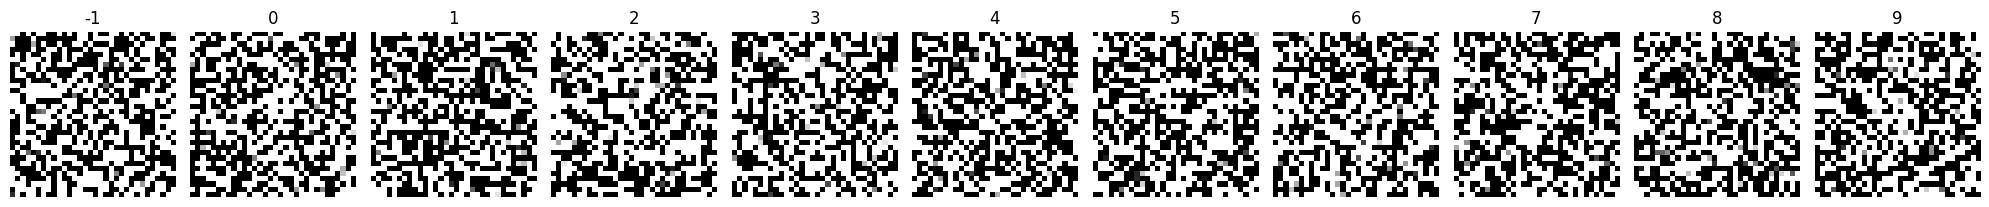

Epoch 5/50
468/468 [==============================] - 43s 92ms/step - noise_loss: 0.0688 - val_loss: 0.9702 - val_noise_loss: 0.9702 - val_image_loss: 34.2079 - learning_rate: 0.0024


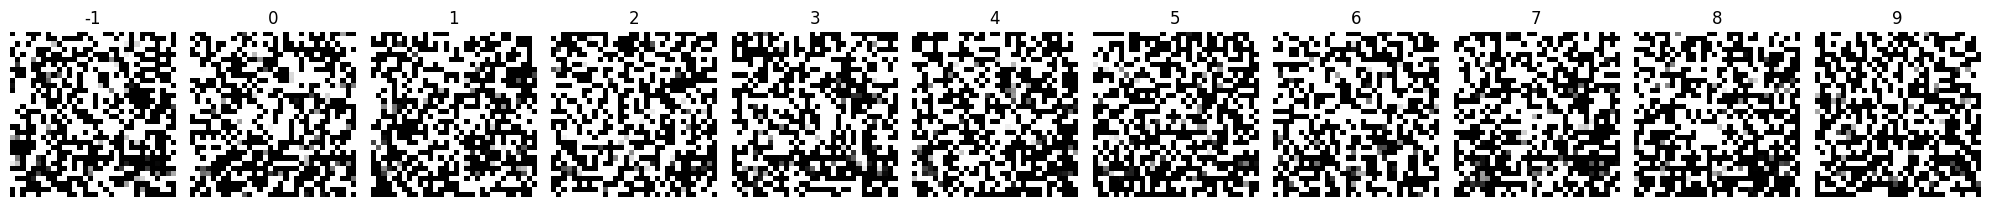

Epoch 6/50
468/468 [==============================] - 44s 92ms/step - noise_loss: 0.0608 - val_loss: 0.8138 - val_noise_loss: 0.8138 - val_image_loss: 26.6889 - learning_rate: 0.0024


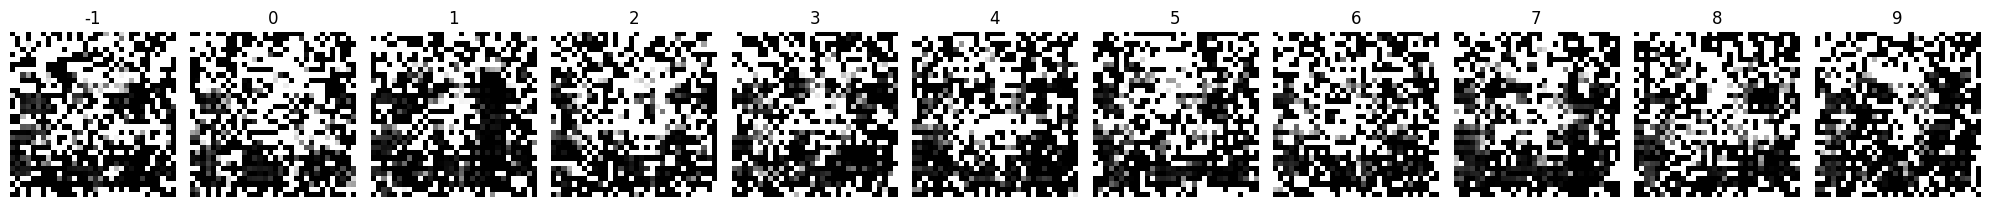

Epoch 7/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0565 - val_loss: 0.5334 - val_noise_loss: 0.5334 - val_image_loss: 17.4336 - learning_rate: 0.0024


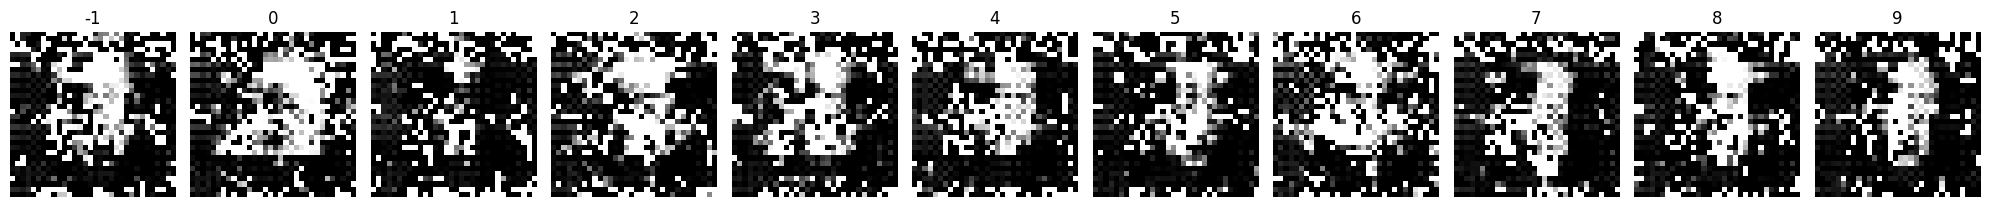

Epoch 8/50
468/468 [==============================] - 52s 112ms/step - noise_loss: 0.1266 - val_loss: 0.2879 - val_noise_loss: 0.2879 - val_image_loss: 6.3576 - learning_rate: 0.0023


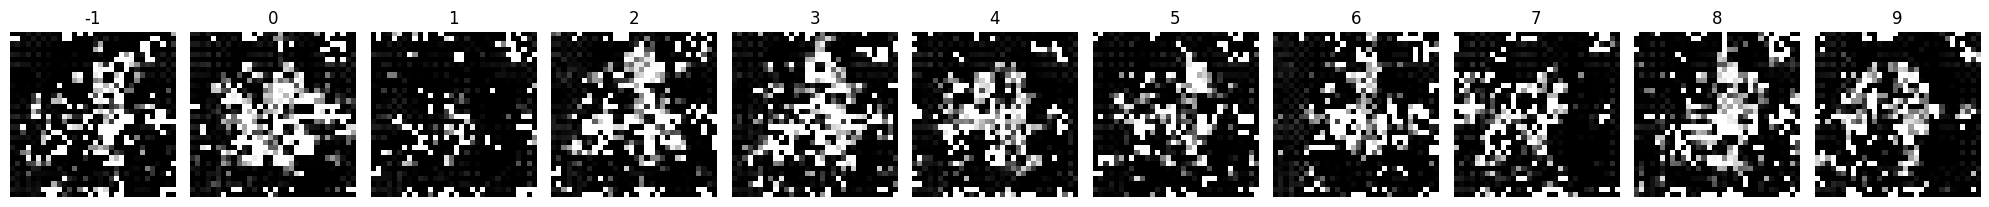

Epoch 9/50
468/468 [==============================] - 58s 123ms/step - noise_loss: 0.0594 - val_loss: 0.3828 - val_noise_loss: 0.3828 - val_image_loss: 9.6508 - learning_rate: 0.0023


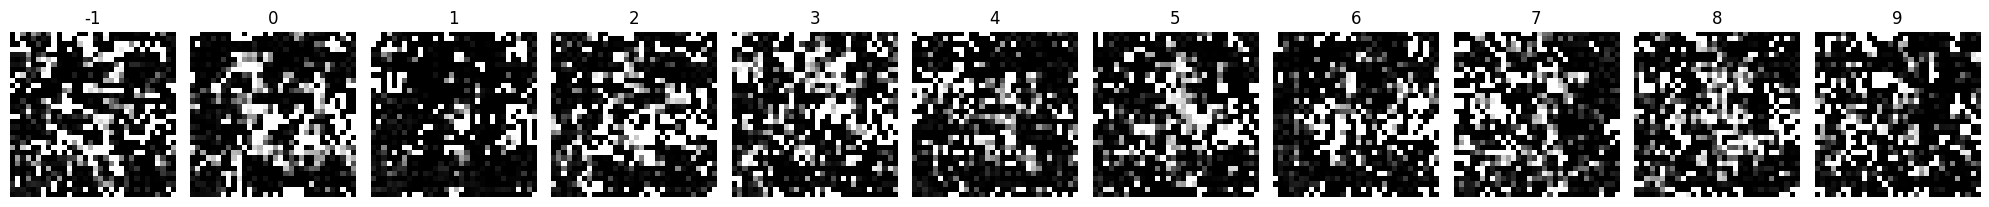

Epoch 10/50
468/468 [==============================] - 58s 123ms/step - noise_loss: 0.0524 - val_loss: 0.1874 - val_noise_loss: 0.1874 - val_image_loss: 3.8383 - learning_rate: 0.0023


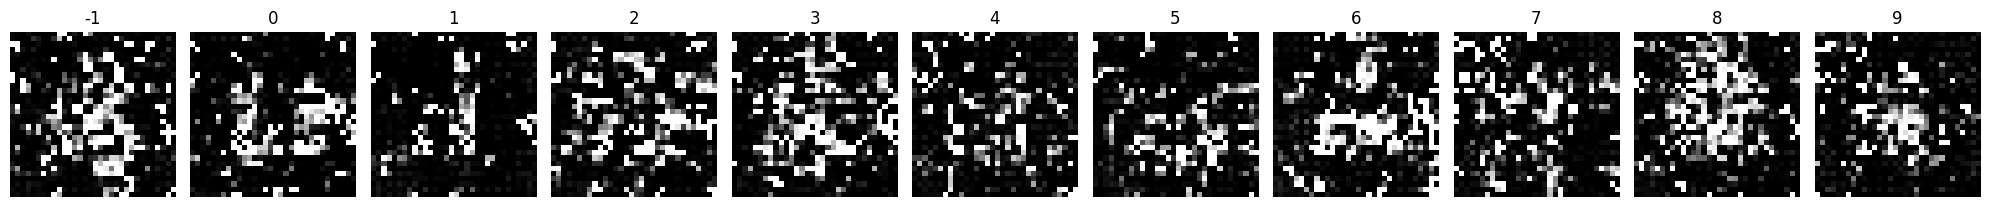

Epoch 11/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0477 - val_loss: 0.0976 - val_noise_loss: 0.0976 - val_image_loss: 1.2433 - learning_rate: 0.0022


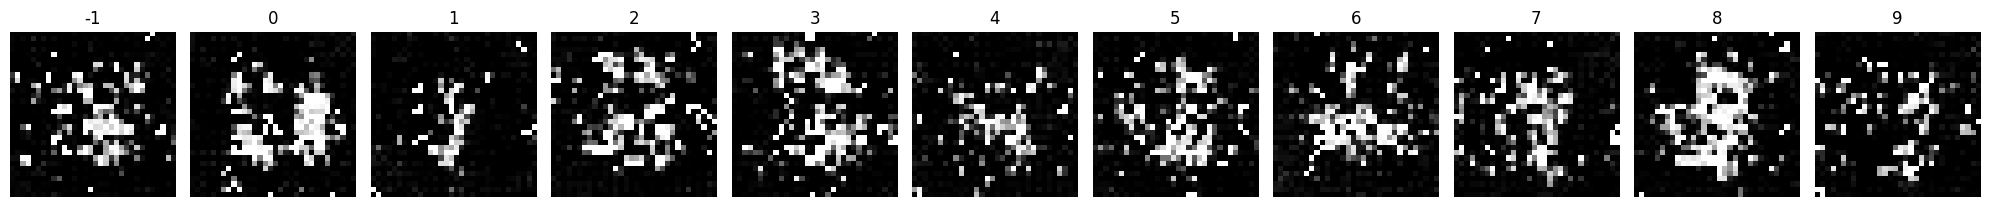

Epoch 12/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0434 - val_loss: 0.0718 - val_noise_loss: 0.0718 - val_image_loss: 0.5728 - learning_rate: 0.0022


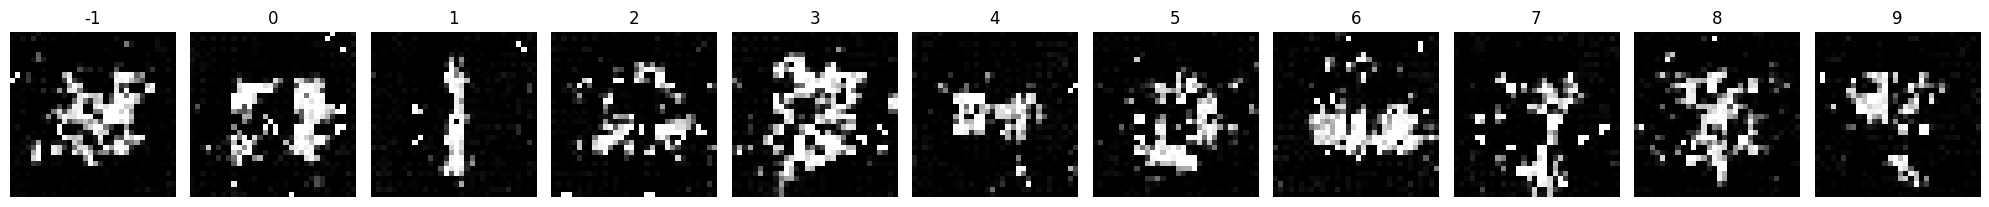

Epoch 13/50
468/468 [==============================] - 55s 117ms/step - noise_loss: 0.0417 - val_loss: 0.0604 - val_noise_loss: 0.0604 - val_image_loss: 0.3845 - learning_rate: 0.0021


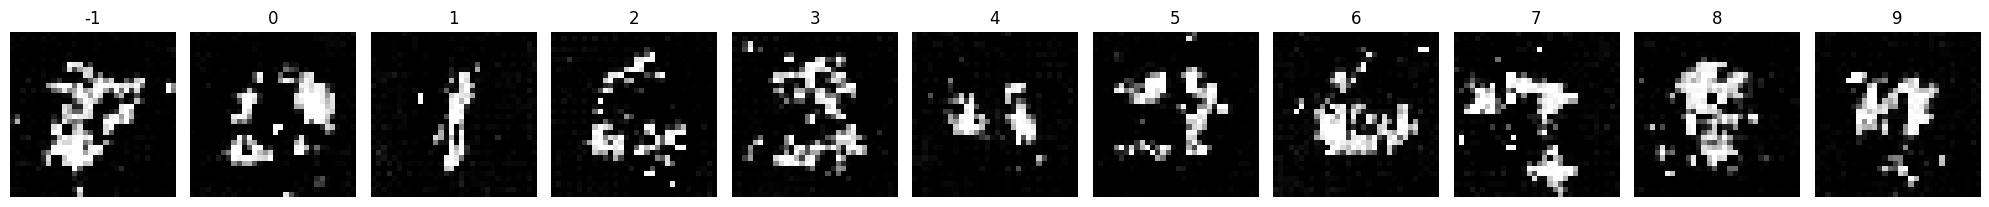

Epoch 14/50
468/468 [==============================] - 57s 121ms/step - noise_loss: 0.0408 - val_loss: 0.0566 - val_noise_loss: 0.0566 - val_image_loss: 0.3004 - learning_rate: 0.0020


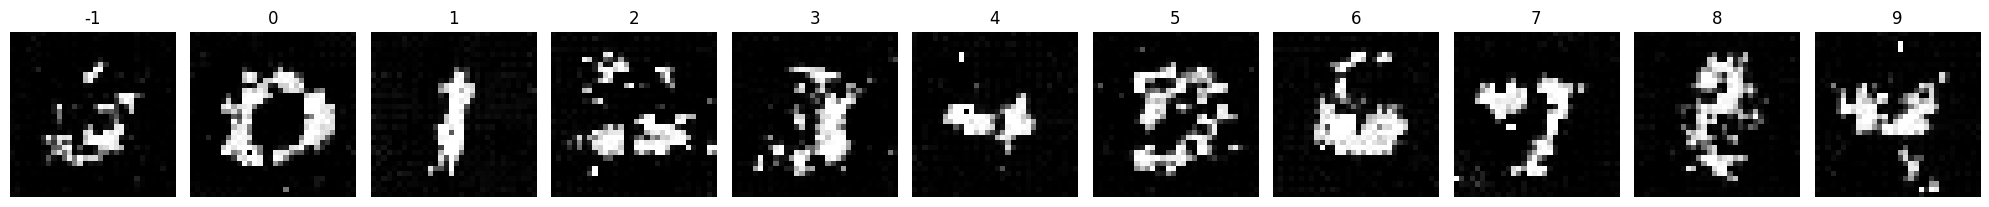

Epoch 15/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0593 - val_loss: 0.0560 - val_noise_loss: 0.0560 - val_image_loss: 0.3382 - learning_rate: 0.0020


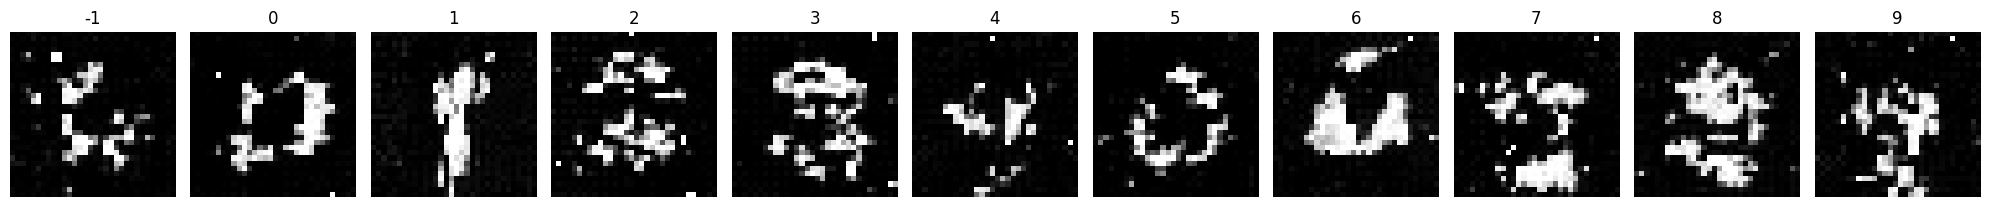

Epoch 16/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0415 - val_loss: 0.0536 - val_noise_loss: 0.0536 - val_image_loss: 0.2844 - learning_rate: 0.0019


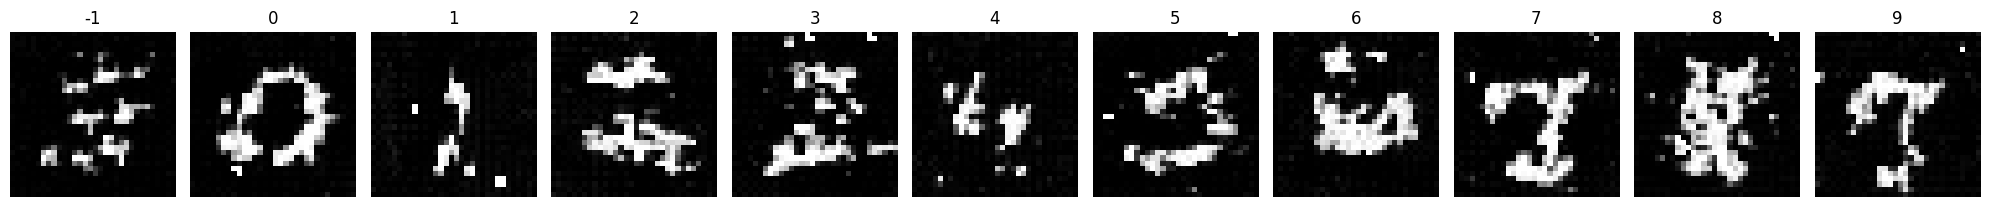

Epoch 17/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0405 - val_loss: 0.0541 - val_noise_loss: 0.0541 - val_image_loss: 0.2588 - learning_rate: 0.0019


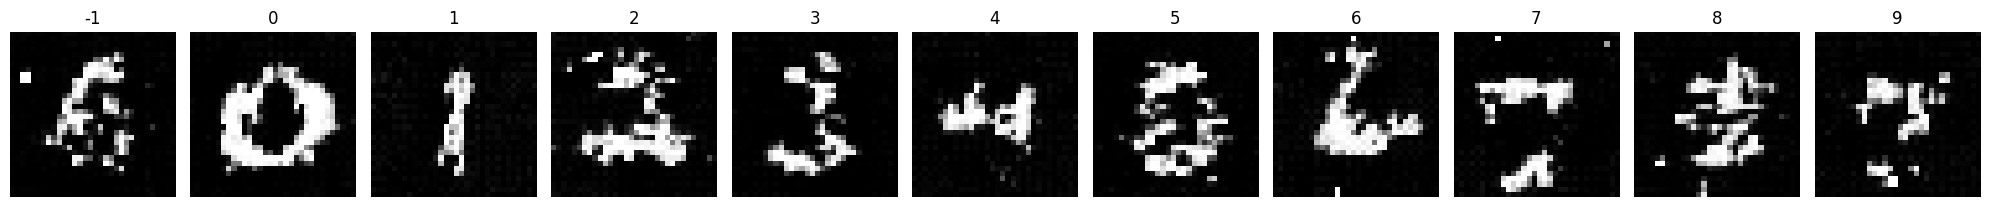

Epoch 18/50
468/468 [==============================] - 54s 116ms/step - noise_loss: 0.0396 - val_loss: 0.0542 - val_noise_loss: 0.0542 - val_image_loss: 0.2686 - learning_rate: 0.0018


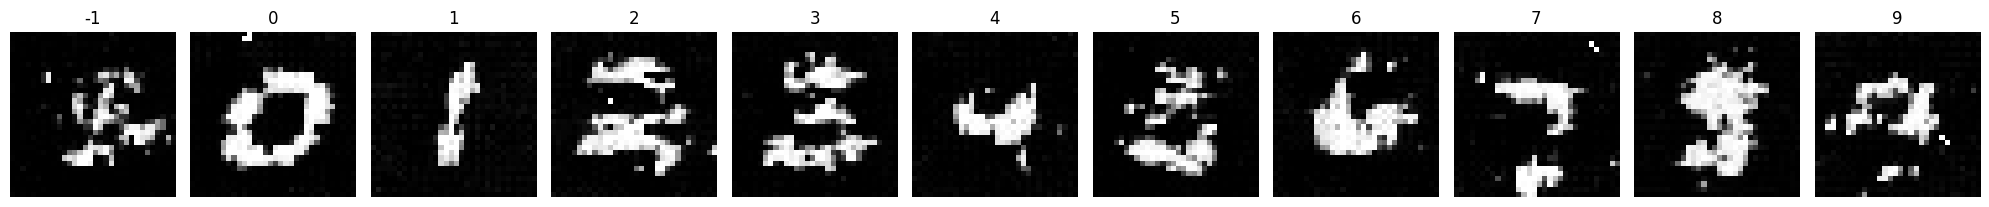

Epoch 19/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0389 - val_loss: 0.0551 - val_noise_loss: 0.0551 - val_image_loss: 0.2712 - learning_rate: 0.0017


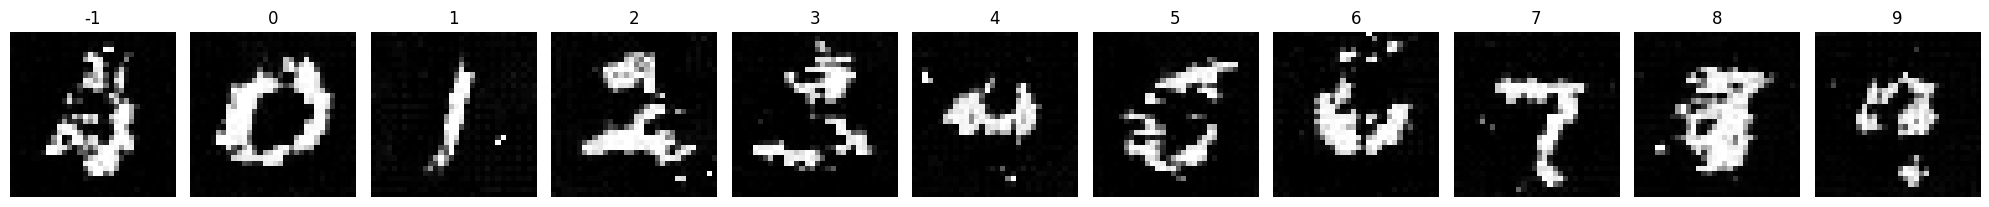

Epoch 20/50
468/468 [==============================] - 55s 117ms/step - noise_loss: 0.0386 - val_loss: 0.0572 - val_noise_loss: 0.0572 - val_image_loss: 0.2570 - learning_rate: 0.0016


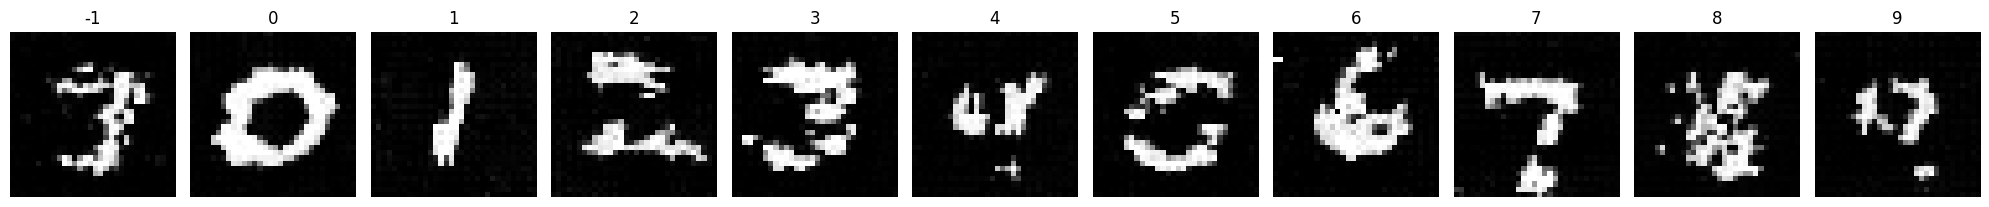

Epoch 21/50
468/468 [==============================] - 56s 120ms/step - noise_loss: 0.0381 - val_loss: 0.0569 - val_noise_loss: 0.0569 - val_image_loss: 0.2883 - learning_rate: 0.0016


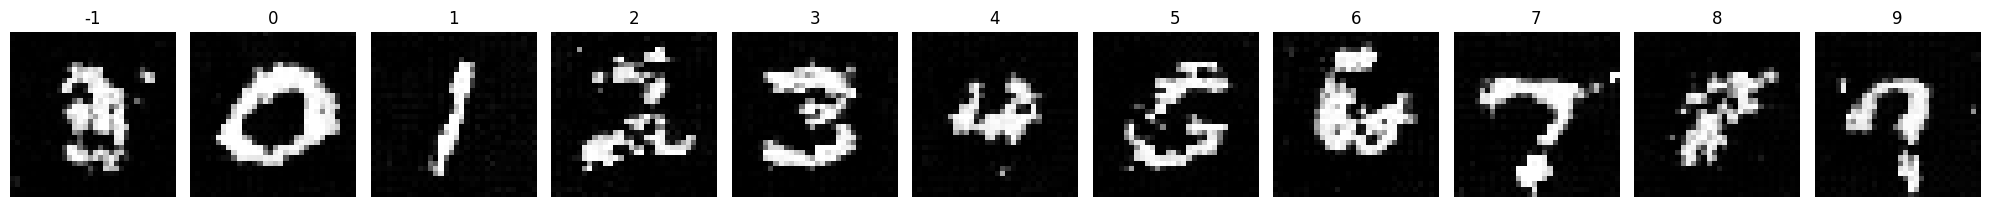

Epoch 22/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0377 - val_loss: 0.0574 - val_noise_loss: 0.0574 - val_image_loss: 0.2694 - learning_rate: 0.0015


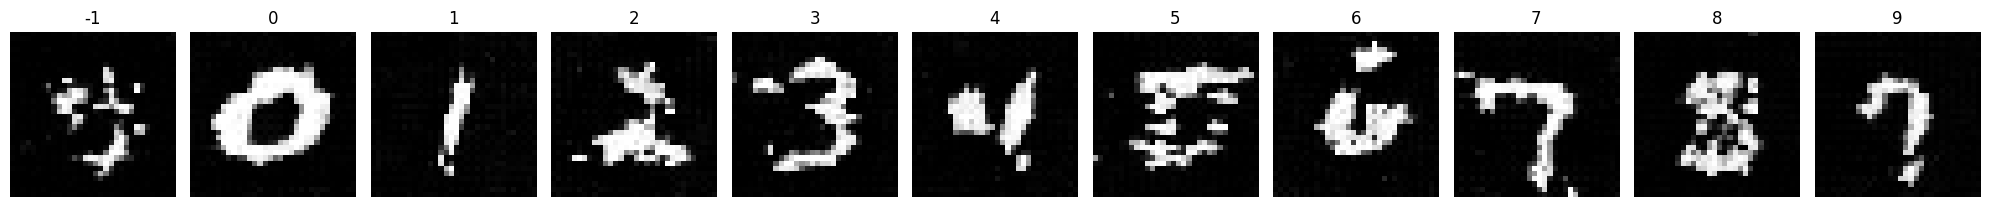

Epoch 23/50
468/468 [==============================] - 55s 117ms/step - noise_loss: 0.0371 - val_loss: 0.0583 - val_noise_loss: 0.0583 - val_image_loss: 0.2933 - learning_rate: 0.0014


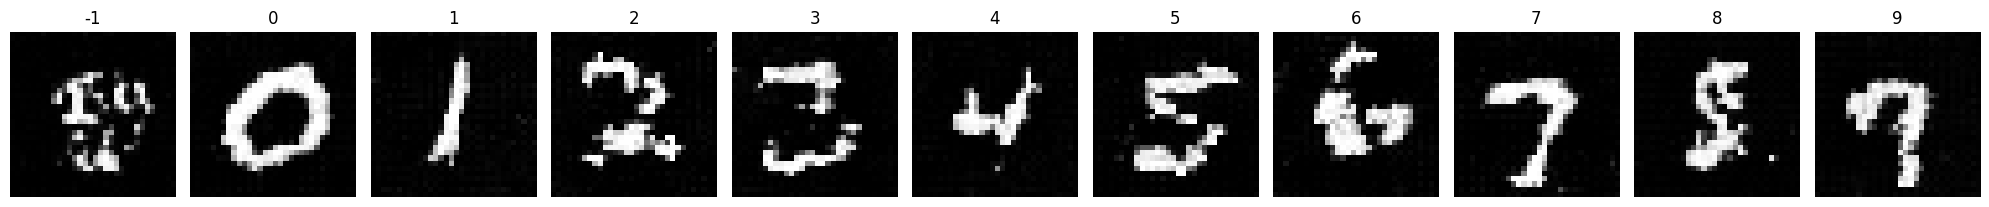

Epoch 24/50
468/468 [==============================] - 54s 116ms/step - noise_loss: 0.0367 - val_loss: 0.0594 - val_noise_loss: 0.0594 - val_image_loss: 0.3070 - learning_rate: 0.0013


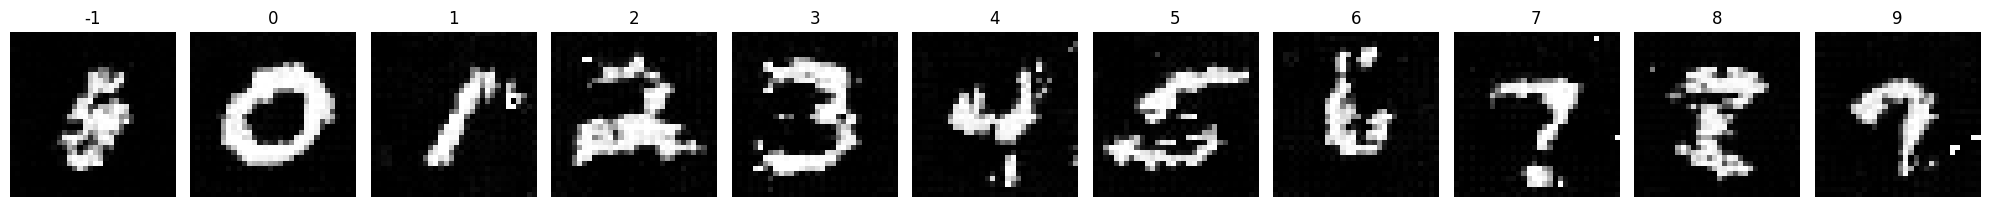

Epoch 25/50
468/468 [==============================] - 54s 116ms/step - noise_loss: 0.0364 - val_loss: 0.0602 - val_noise_loss: 0.0602 - val_image_loss: 0.2886 - learning_rate: 0.0012


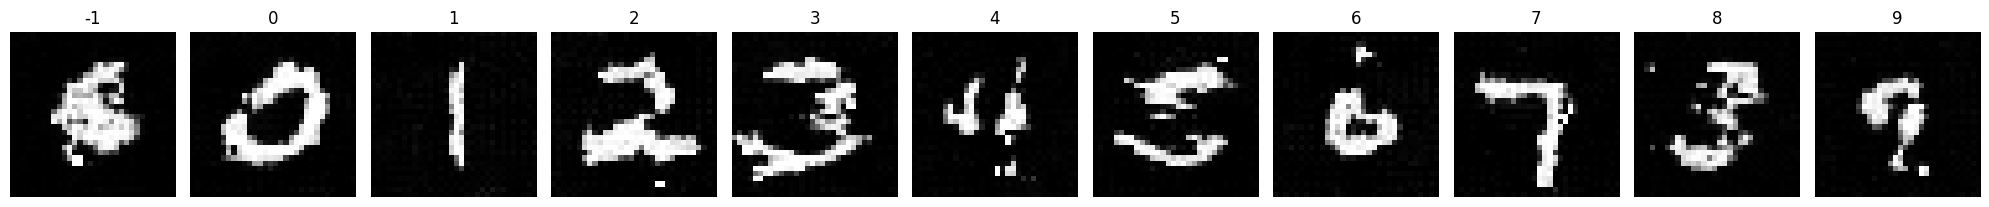

Epoch 26/50
468/468 [==============================] - 54s 116ms/step - noise_loss: 0.0360 - val_loss: 0.0608 - val_noise_loss: 0.0608 - val_image_loss: 0.2963 - learning_rate: 0.0012


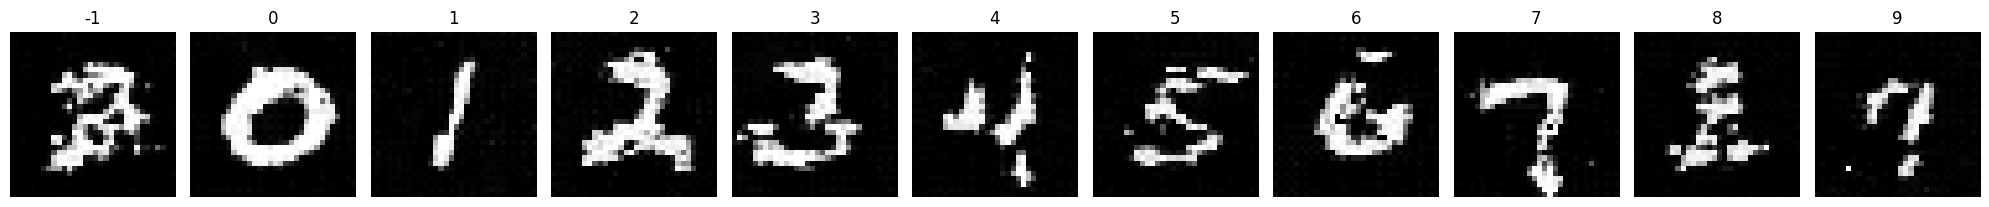

Epoch 27/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0355 - val_loss: 0.0610 - val_noise_loss: 0.0610 - val_image_loss: 0.3096 - learning_rate: 0.0011


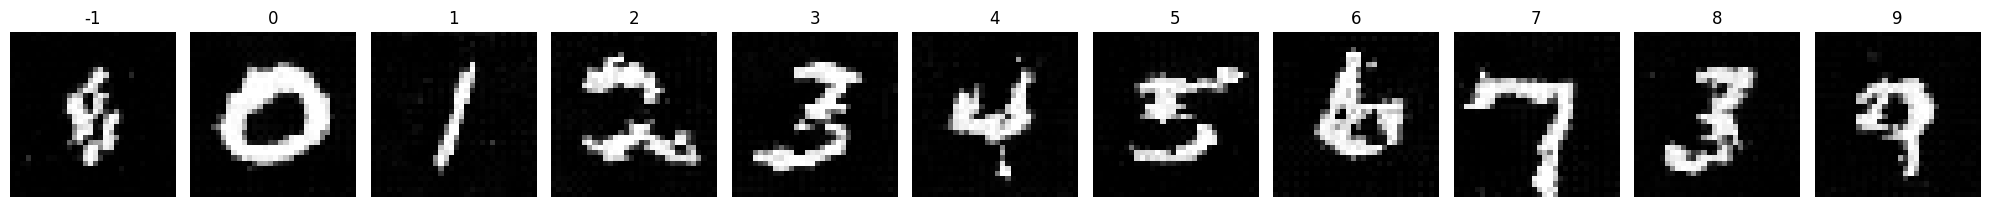

Epoch 28/50
468/468 [==============================] - 55s 117ms/step - noise_loss: 0.0353 - val_loss: 0.0617 - val_noise_loss: 0.0617 - val_image_loss: 0.2929 - learning_rate: 0.0010


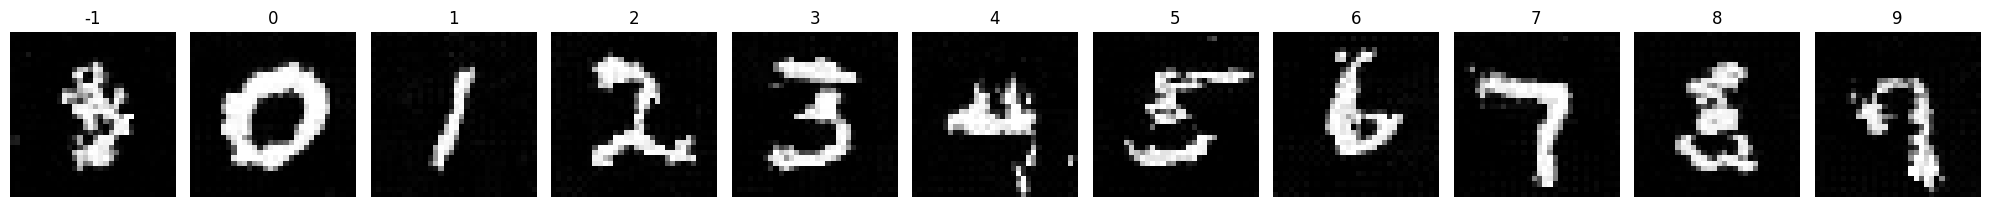

Epoch 29/50
468/468 [==============================] - 55s 117ms/step - noise_loss: 0.0349 - val_loss: 0.0625 - val_noise_loss: 0.0625 - val_image_loss: 0.2984 - learning_rate: 9.3914e-04


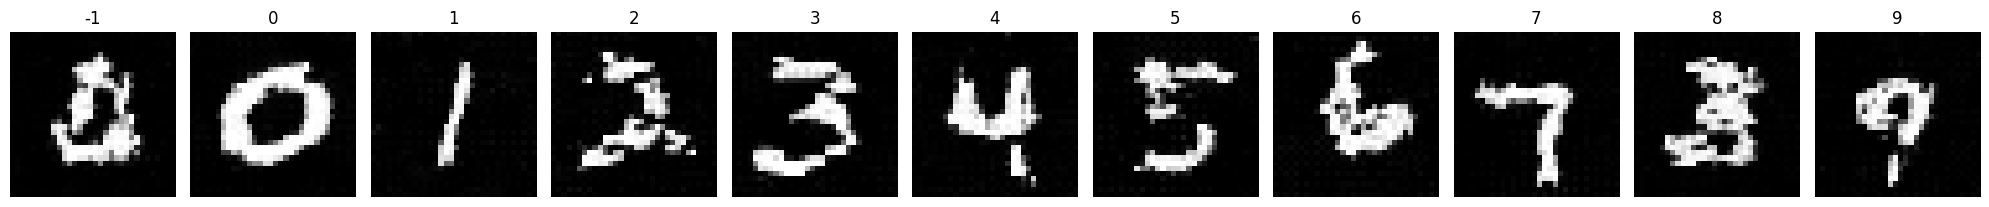

Epoch 30/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0346 - val_loss: 0.0620 - val_noise_loss: 0.0620 - val_image_loss: 0.3068 - learning_rate: 8.6373e-04


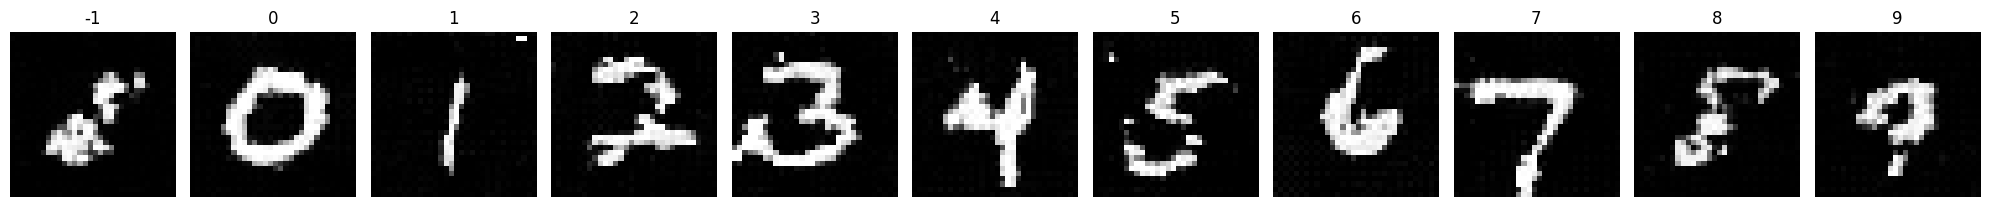

Epoch 31/50
468/468 [==============================] - 54s 116ms/step - noise_loss: 0.0343 - val_loss: 0.0629 - val_noise_loss: 0.0629 - val_image_loss: 0.3118 - learning_rate: 7.8984e-04


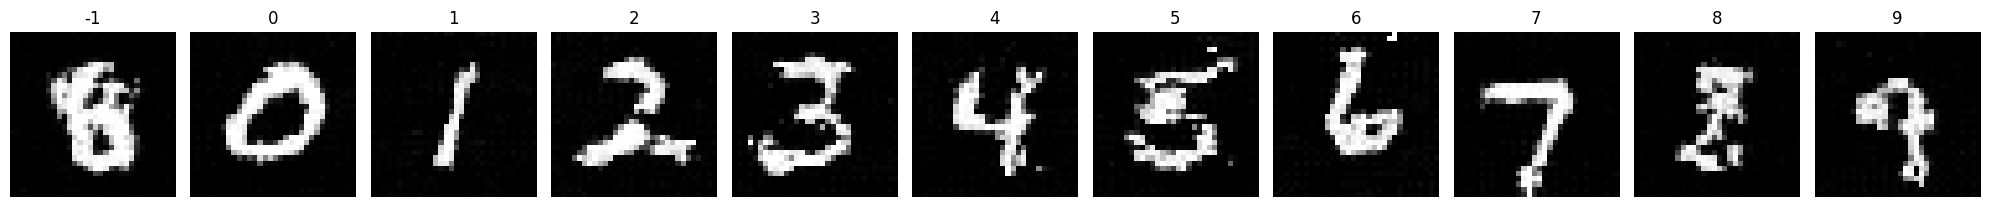

Epoch 32/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0343 - val_loss: 0.0623 - val_noise_loss: 0.0623 - val_image_loss: 0.3172 - learning_rate: 7.1778e-04


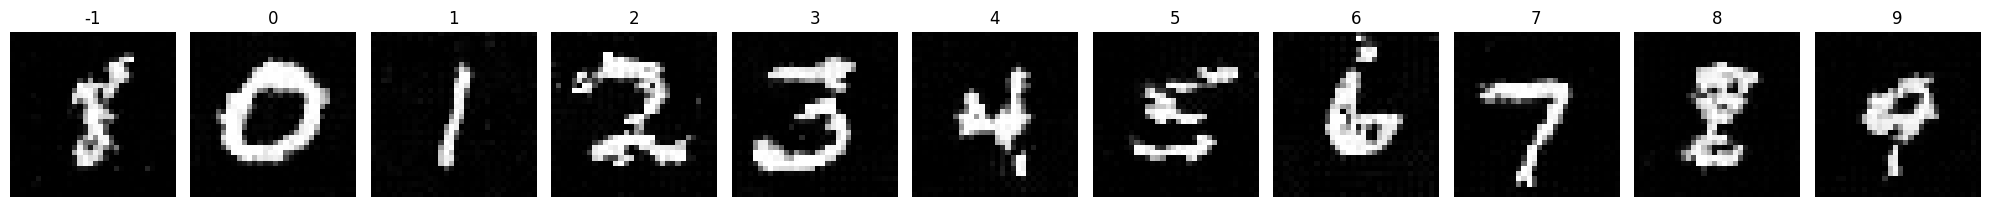

Epoch 33/50
468/468 [==============================] - 55s 118ms/step - noise_loss: 0.0340 - val_loss: 0.0631 - val_noise_loss: 0.0631 - val_image_loss: 0.2998 - learning_rate: 6.4781e-04


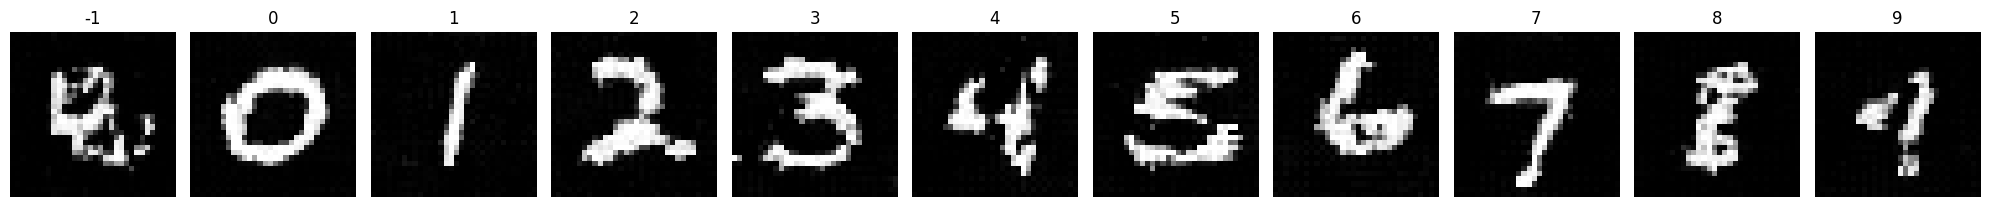

Epoch 34/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0337 - val_loss: 0.0630 - val_noise_loss: 0.0630 - val_image_loss: 0.2970 - learning_rate: 5.8022e-04


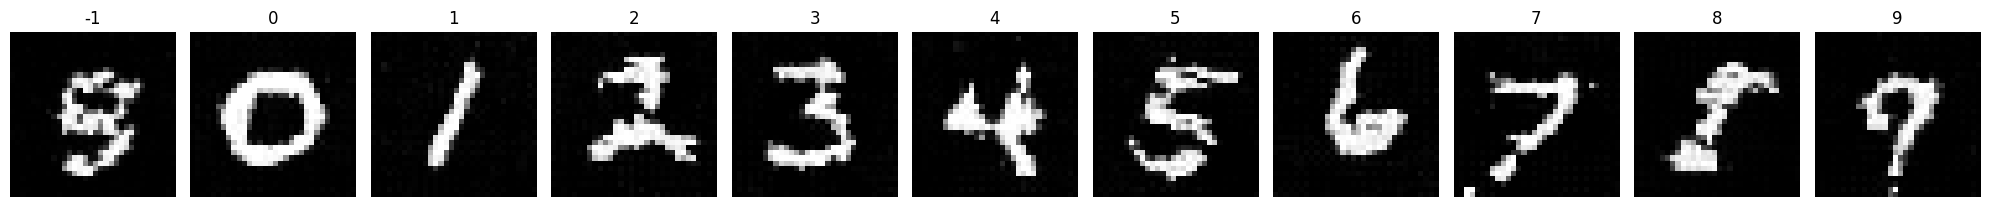

Epoch 35/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0334 - val_loss: 0.0632 - val_noise_loss: 0.0632 - val_image_loss: 0.3065 - learning_rate: 5.1527e-04


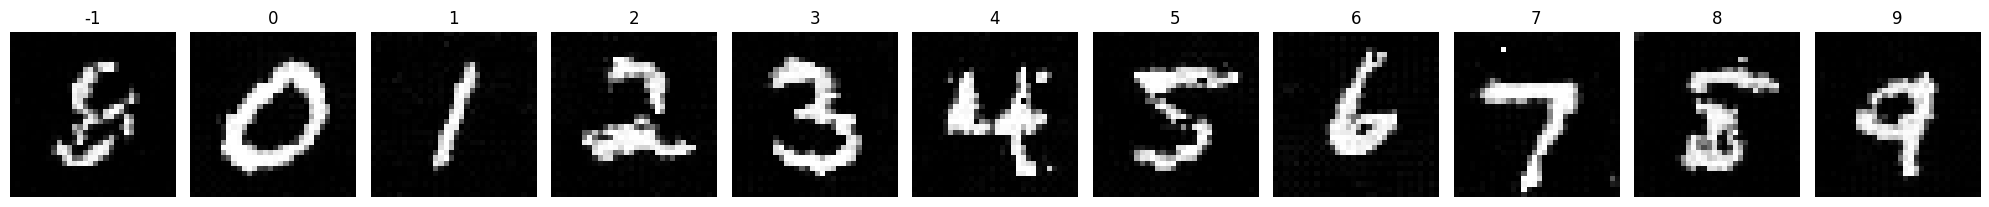

Epoch 36/50
468/468 [==============================] - 56s 119ms/step - noise_loss: 0.0333 - val_loss: 0.0636 - val_noise_loss: 0.0636 - val_image_loss: 0.3030 - learning_rate: 4.5322e-04


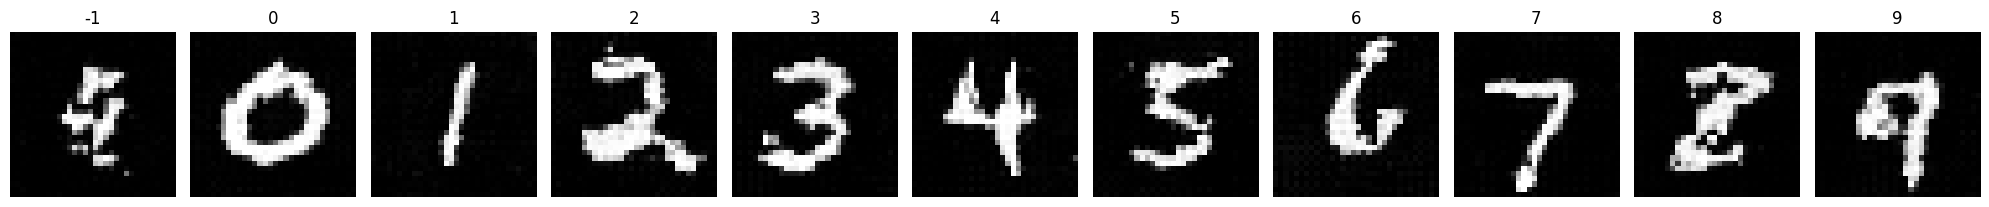

Epoch 37/50
468/468 [==============================] - 53s 112ms/step - noise_loss: 0.0332 - val_loss: 0.0635 - val_noise_loss: 0.0635 - val_image_loss: 0.3013 - learning_rate: 3.9432e-04


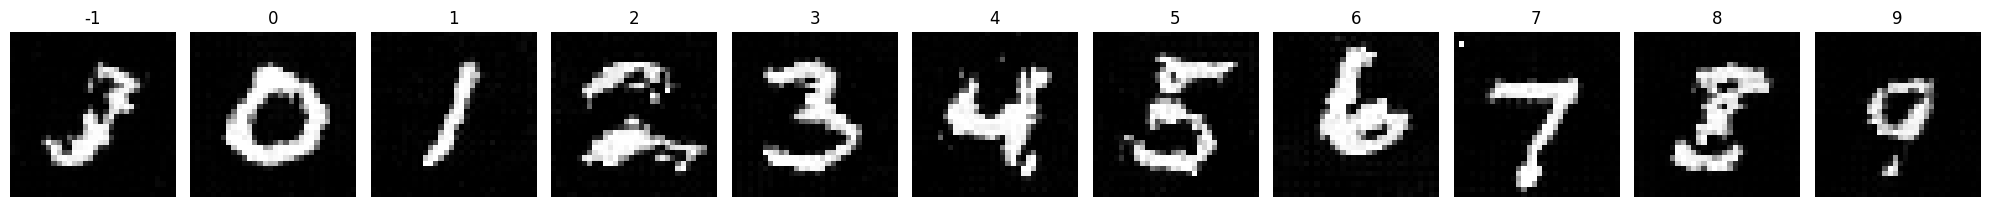

Epoch 38/50
468/468 [==============================] - 53s 113ms/step - noise_loss: 0.0330 - val_loss: 0.0634 - val_noise_loss: 0.0634 - val_image_loss: 0.2953 - learning_rate: 3.3879e-04


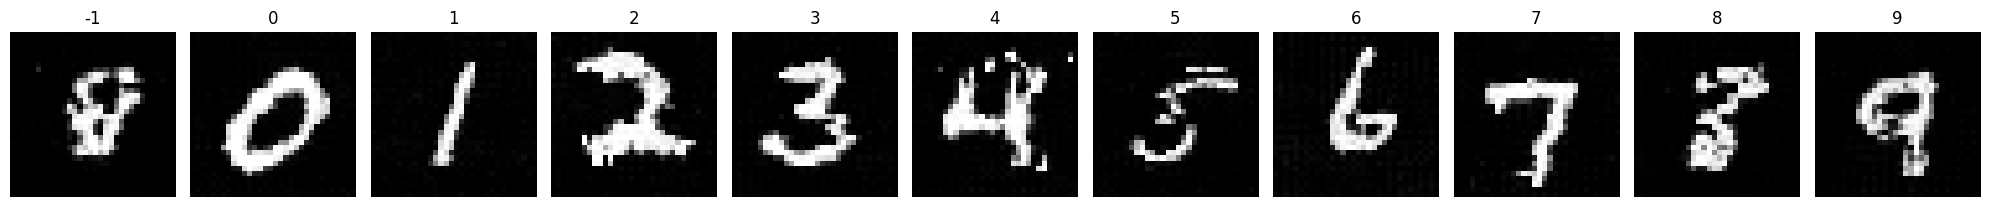

Epoch 39/50
468/468 [==============================] - 53s 112ms/step - noise_loss: 0.0329 - val_loss: 0.0642 - val_noise_loss: 0.0642 - val_image_loss: 0.3059 - learning_rate: 2.8686e-04


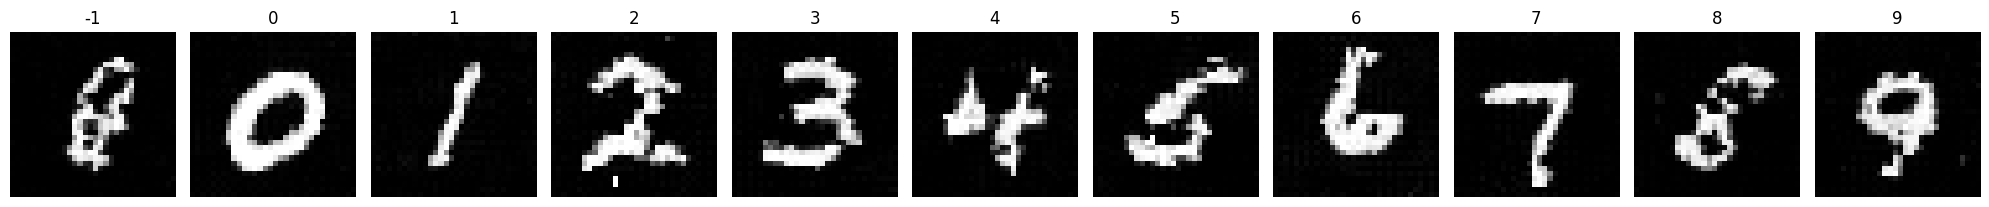

Epoch 40/50
468/468 [==============================] - 53s 112ms/step - noise_loss: 0.0327 - val_loss: 0.0647 - val_noise_loss: 0.0647 - val_image_loss: 0.3087 - learning_rate: 2.3873e-04


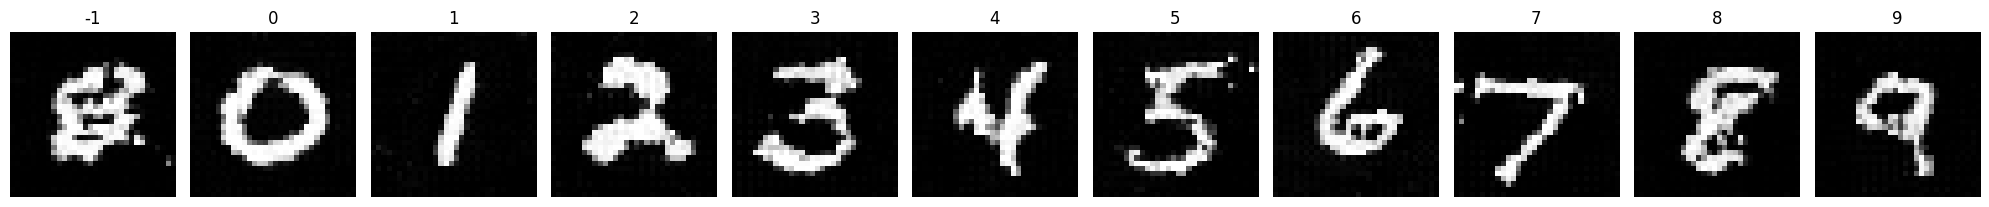

Epoch 41/50
468/468 [==============================] - 53s 114ms/step - noise_loss: 0.0327 - val_loss: 0.0645 - val_noise_loss: 0.0645 - val_image_loss: 0.2882 - learning_rate: 1.9459e-04


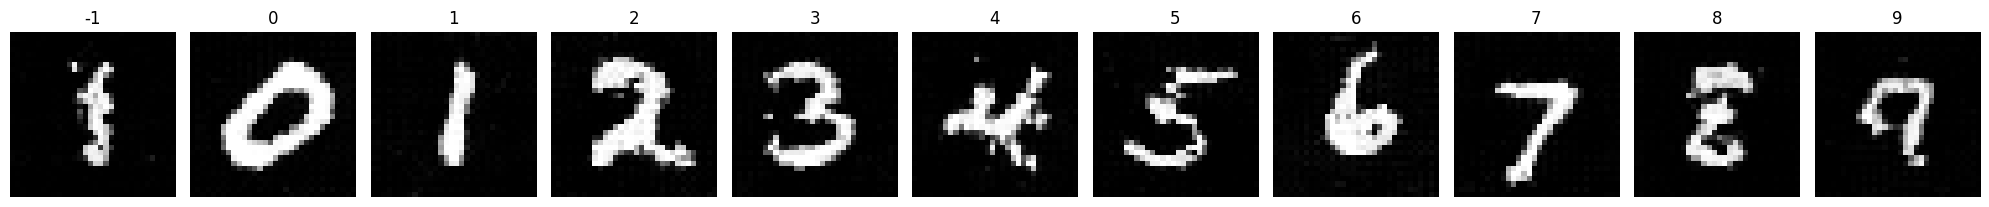

Epoch 42/50
468/468 [==============================] - 53s 112ms/step - noise_loss: 0.0326 - val_loss: 0.0651 - val_noise_loss: 0.0651 - val_image_loss: 0.2958 - learning_rate: 1.5462e-04


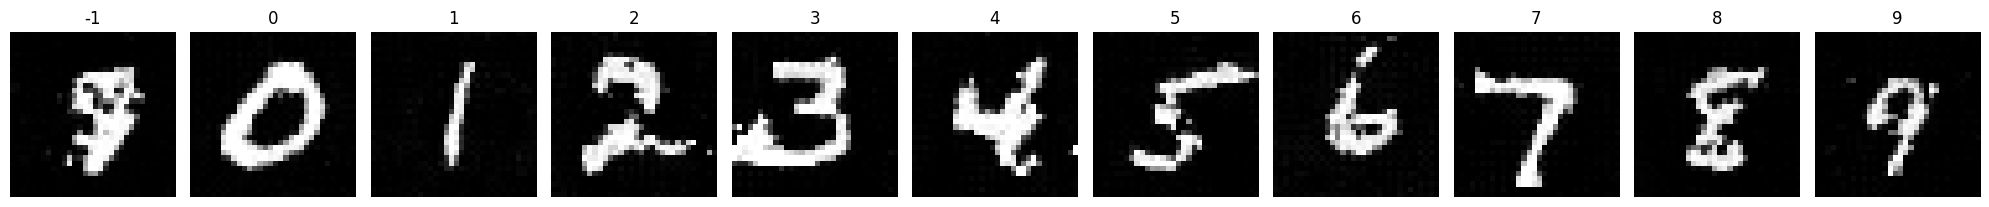

Epoch 43/50
468/468 [==============================] - 53s 114ms/step - noise_loss: 0.0325 - val_loss: 0.0657 - val_noise_loss: 0.0657 - val_image_loss: 0.2994 - learning_rate: 1.1897e-04


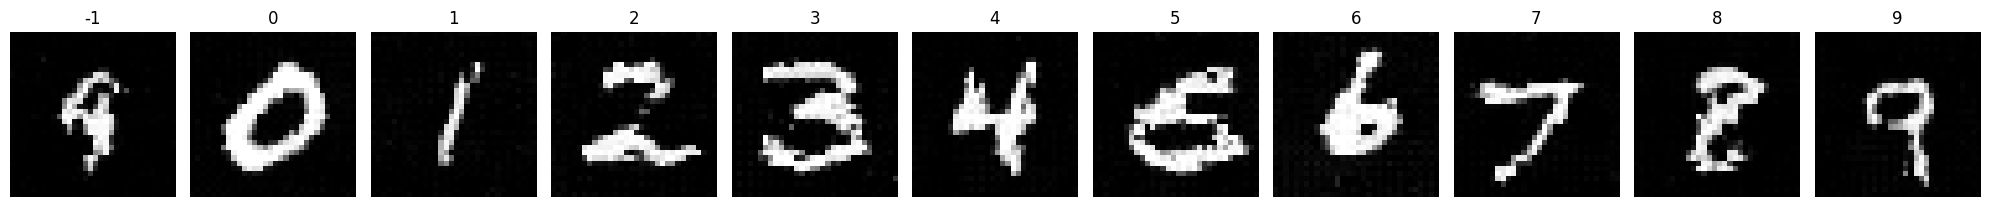

Epoch 44/50
468/468 [==============================] - 52s 111ms/step - noise_loss: 0.0323 - val_loss: 0.0652 - val_noise_loss: 0.0652 - val_image_loss: 0.2976 - learning_rate: 8.7779e-05


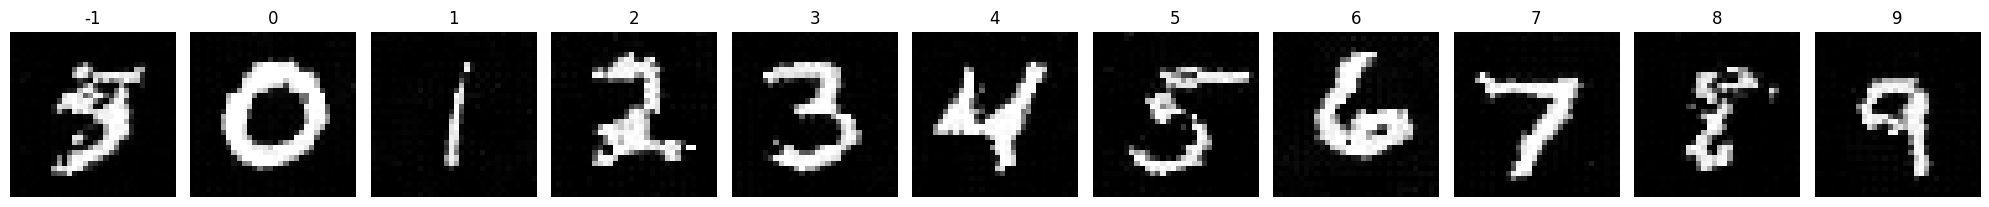

Epoch 45/50
468/468 [==============================] - 52s 112ms/step - noise_loss: 0.0323 - val_loss: 0.0651 - val_noise_loss: 0.0651 - val_image_loss: 0.2974 - learning_rate: 6.1179e-05


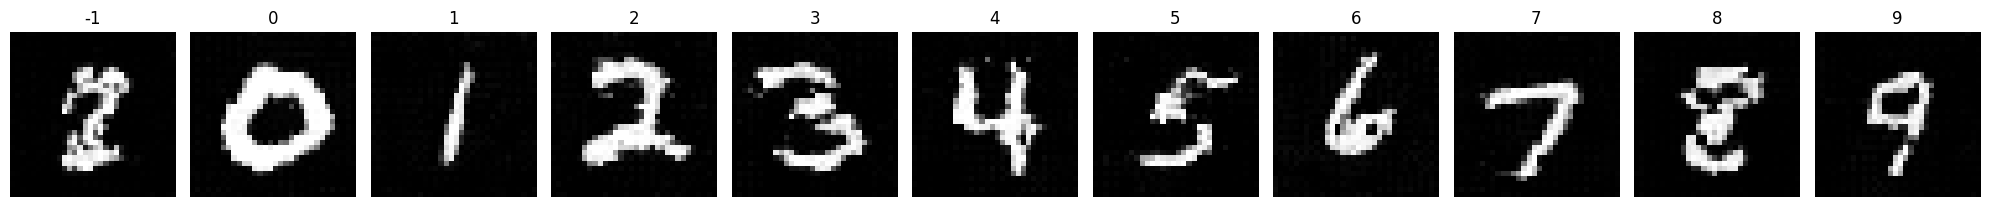

Epoch 46/50
468/468 [==============================] - 53s 113ms/step - noise_loss: 0.0323 - val_loss: 0.0658 - val_noise_loss: 0.0658 - val_image_loss: 0.2973 - learning_rate: 3.9271e-05


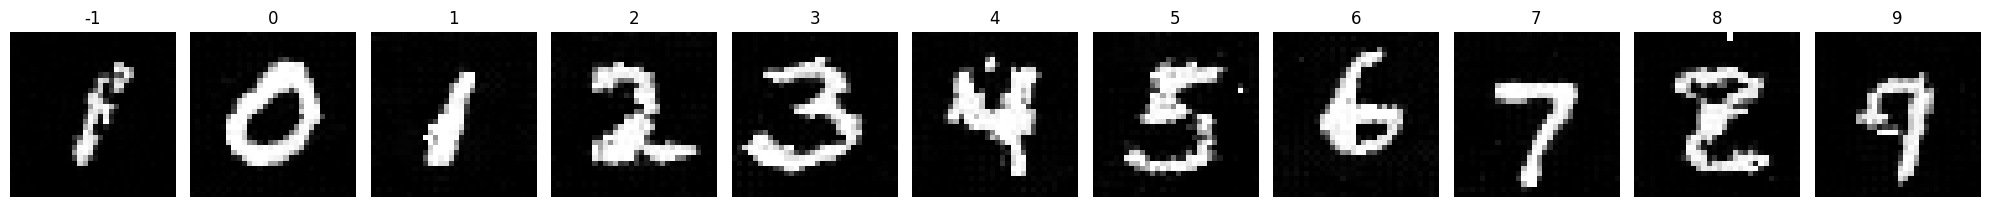

Epoch 47/50
468/468 [==============================] - 52s 111ms/step - noise_loss: 0.0324 - val_loss: 0.0663 - val_noise_loss: 0.0663 - val_image_loss: 0.2912 - learning_rate: 2.2141e-05


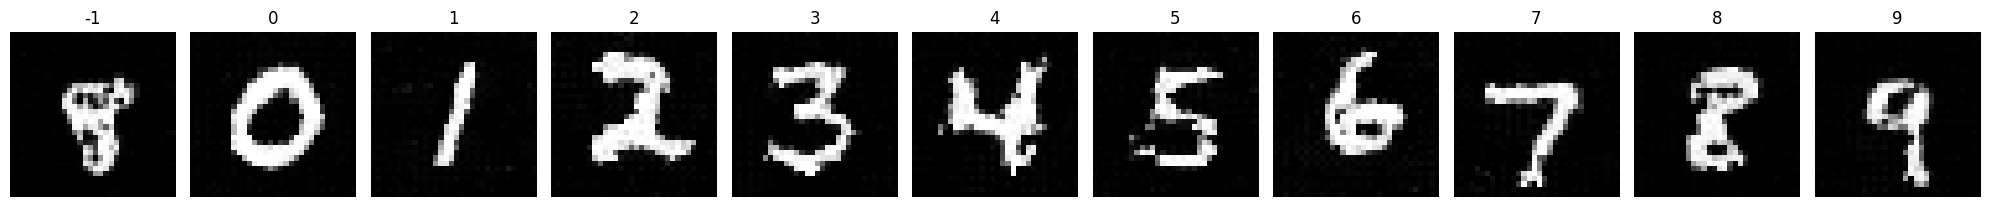

Epoch 48/50
468/468 [==============================] - 54s 114ms/step - noise_loss: 0.0322 - val_loss: 0.0662 - val_noise_loss: 0.0662 - val_image_loss: 0.3023 - learning_rate: 9.8566e-06


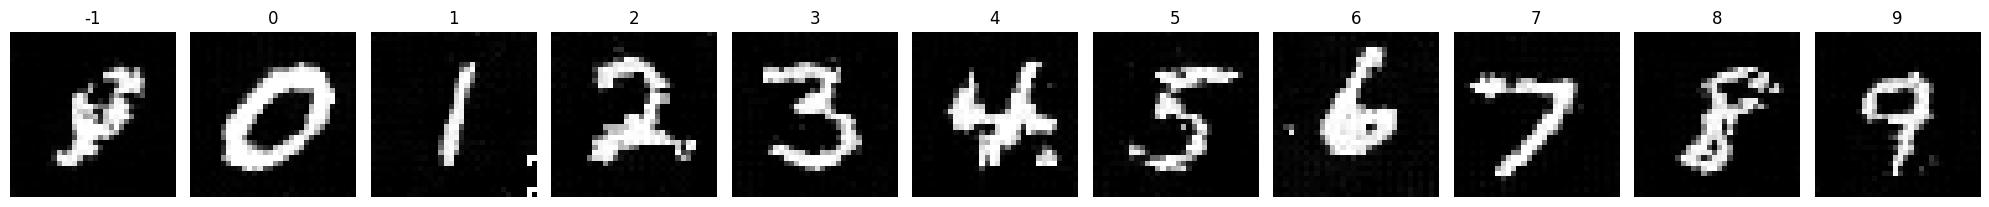

Epoch 49/50
468/468 [==============================] - 54s 114ms/step - noise_loss: 0.0321 - val_loss: 0.0666 - val_noise_loss: 0.0666 - val_image_loss: 0.3462 - learning_rate: 2.4666e-06


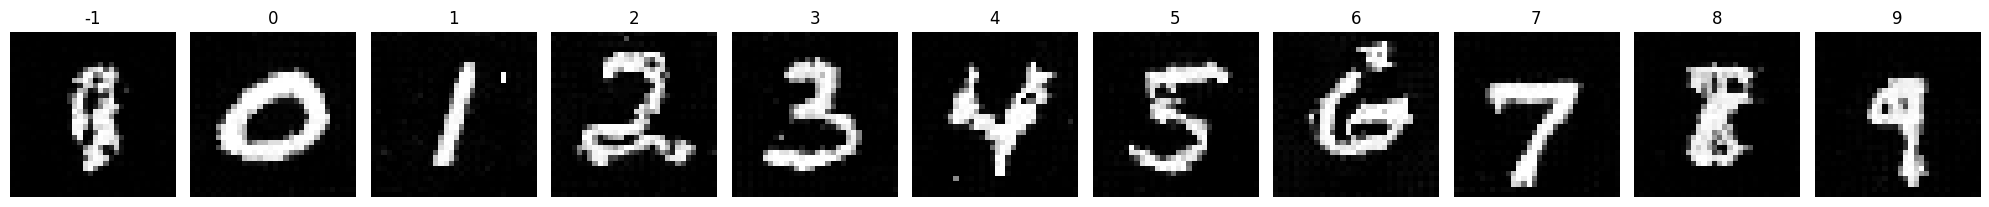

Epoch 50/50
468/468 [==============================] - 53s 113ms/step - noise_loss: 0.0323 - val_loss: 0.0660 - val_noise_loss: 0.0660 - val_image_loss: 0.2953 - learning_rate: 0.0000e+00


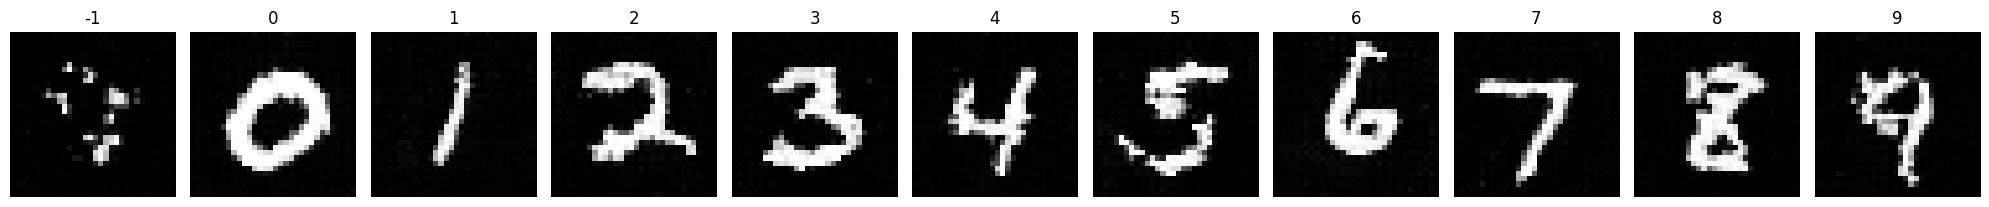

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [ ]:
model.save_weights("./models/U-DiT mini/model.weights.h5")

In [10]:
model.evaluate(valset, network_name="ema")

79/79 [==============================] - 8s 101ms/step - loss: 0.0658 - noise_loss: 0.0658 - image_loss: 0.3141


[0.06583606451749802, 0.06583606451749802, 0.3140706419944763]

In [11]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 11s 99ms/step - loss: 0.0668 - noise_loss: 0.0668 - image_loss: 0.3045


[0.06677086651325226, 0.06677086651325226, 0.3045167922973633]

Steps: 1000/1000


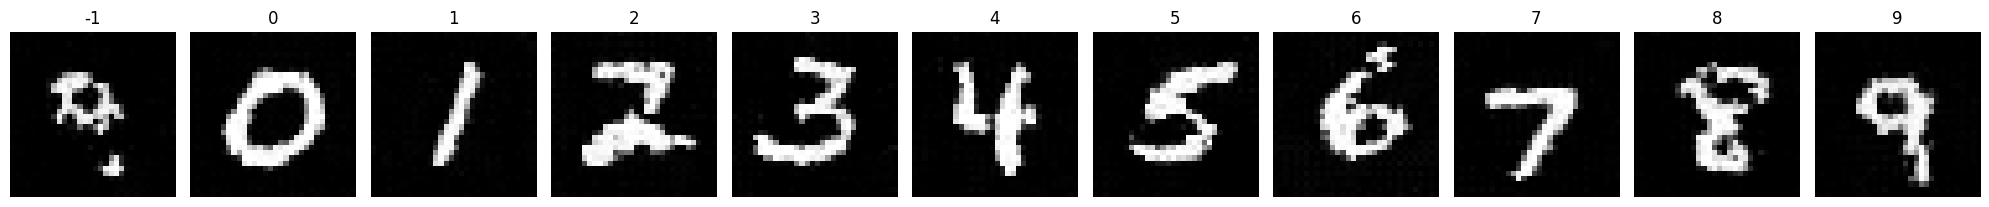

In [12]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


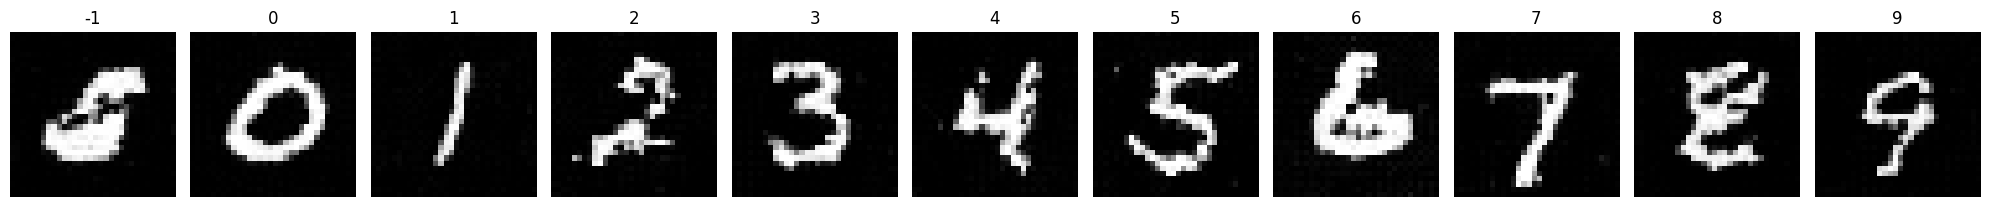

In [13]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


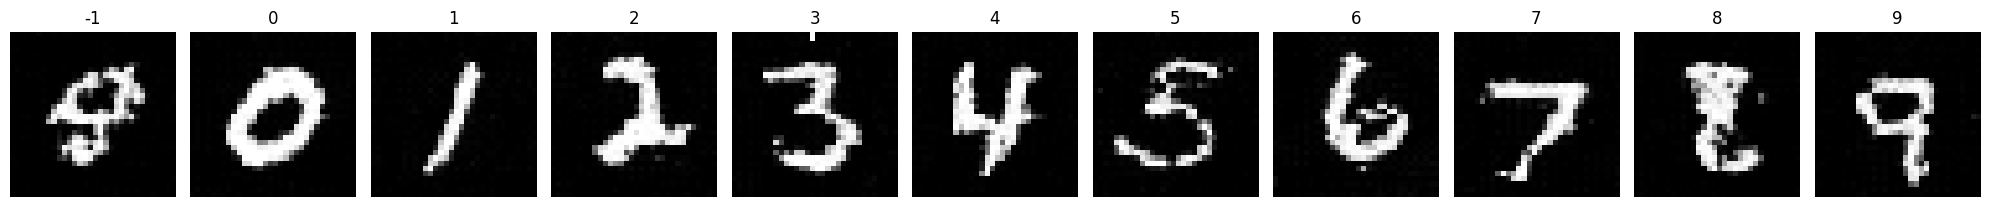

In [14]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


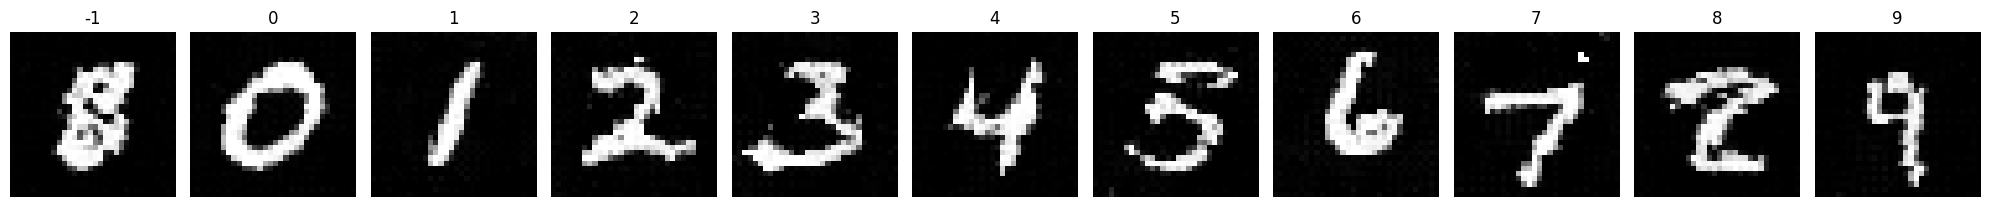

In [15]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

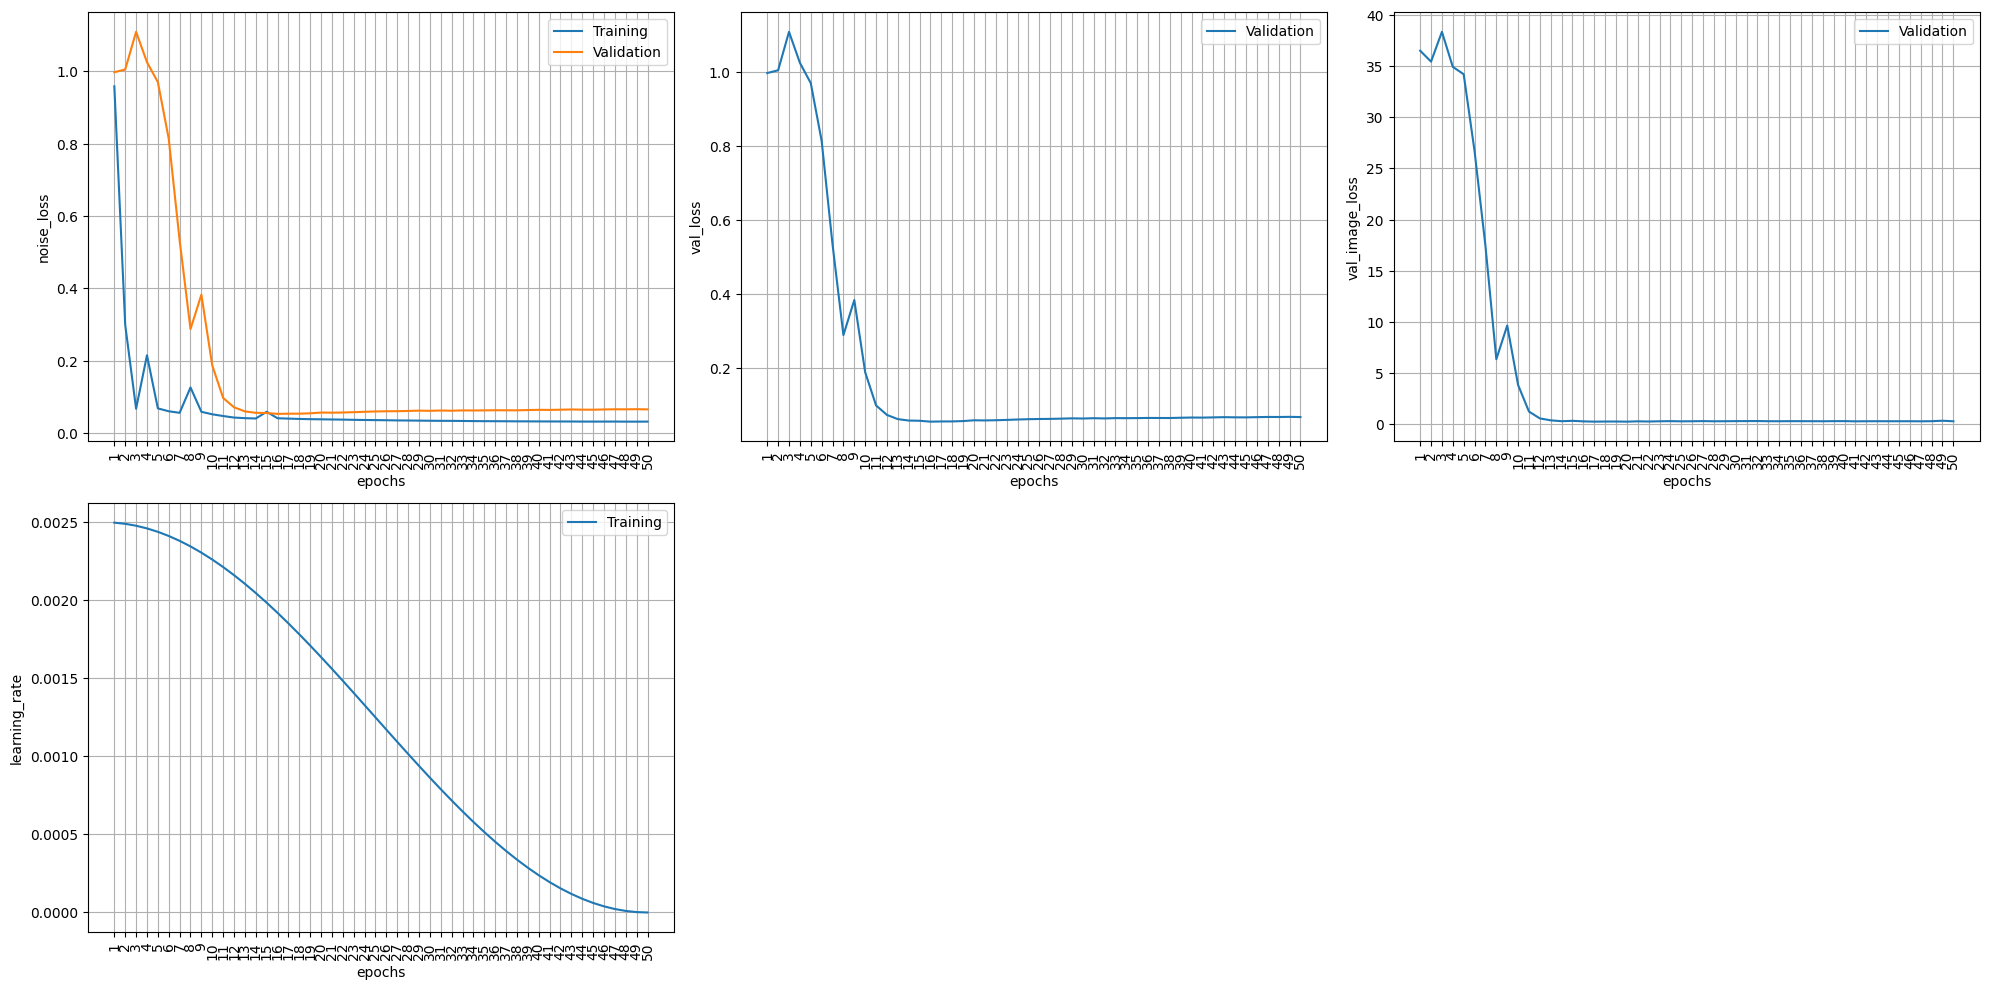

In [16]:
from common.utils import plot_history


plot_history(history)

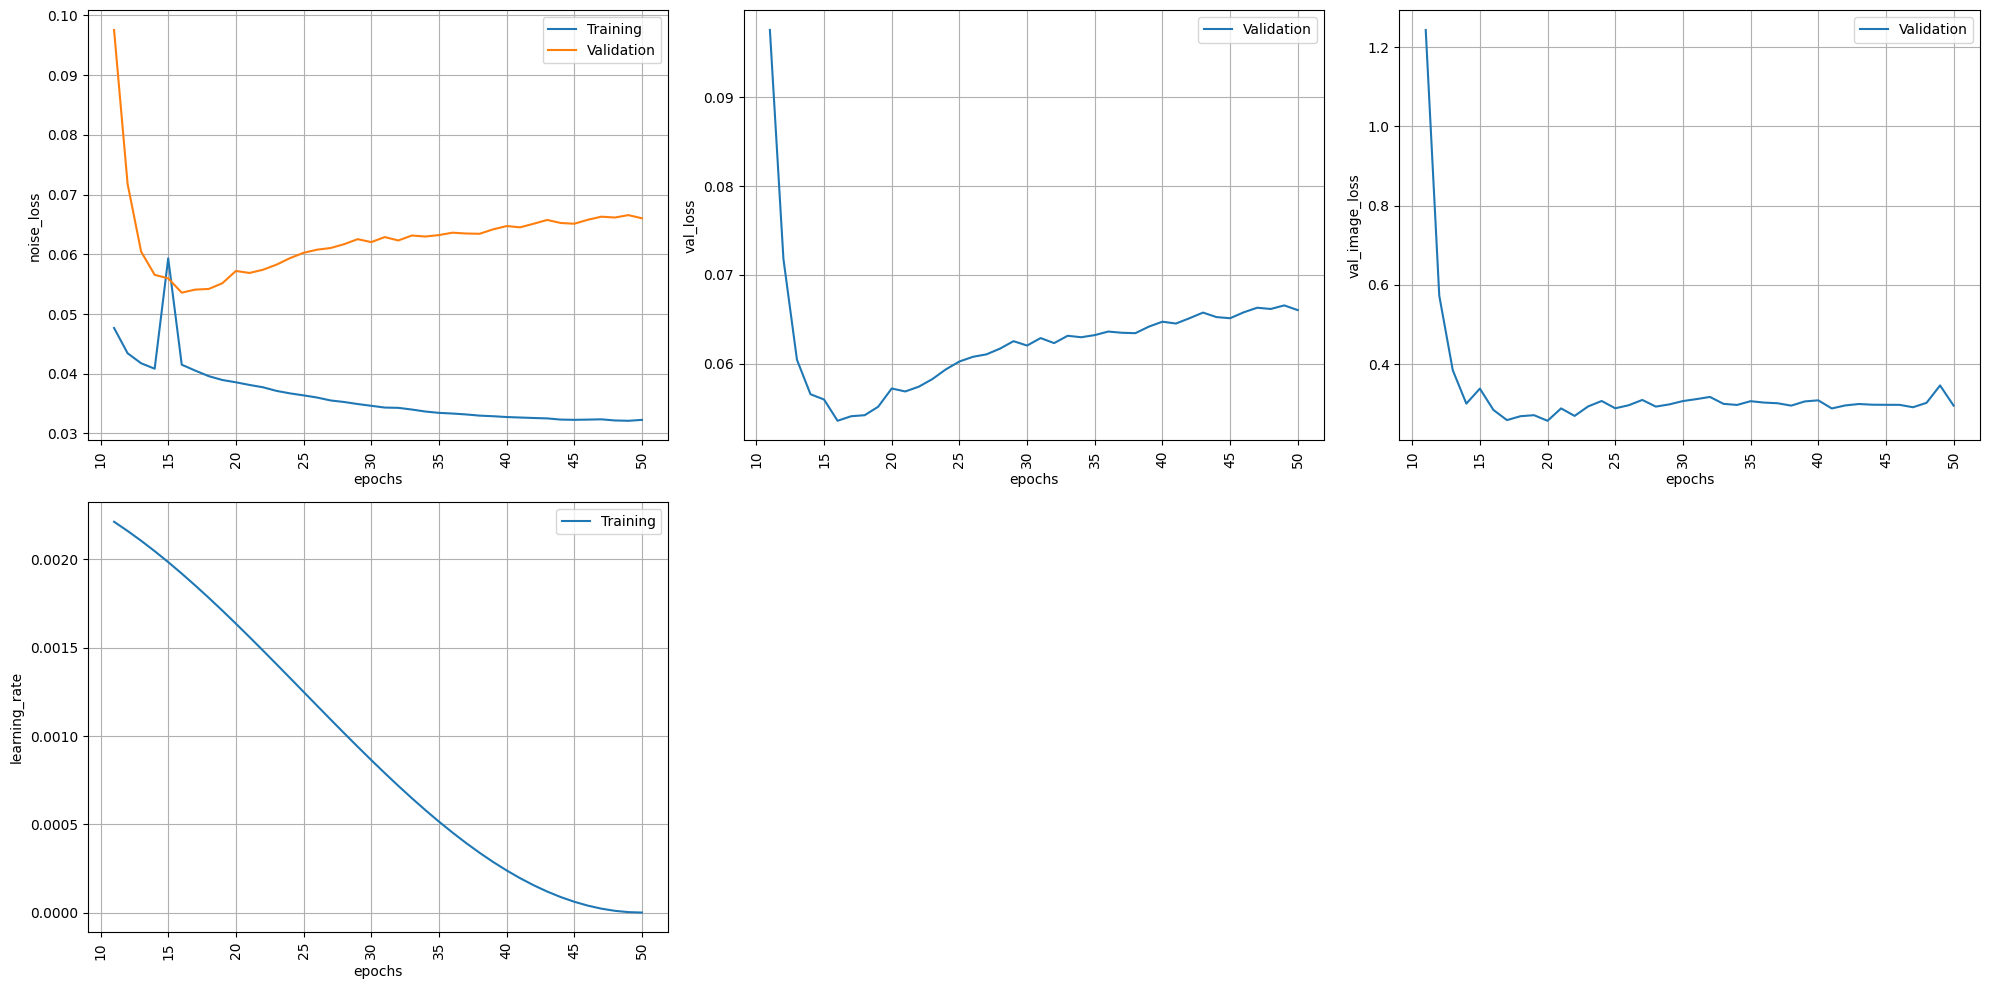

In [17]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))